## IterativeImputer
### This notebook outlines the usage of Iterative Imputer (Multivariate Imputation).
### Iterative Imputer substitutes missing values as a function of other features
#### Dataset: [https://github.com/subashgandyer/datasets/blob/main/heart_disease.csv]

**Demographic**
- Sex: male or female(Nominal)
- Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

**Behavioral**
- Current Smoker: whether or not the patient is a current smoker (Nominal)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)

**Medical(history)**
- BP Meds: whether or not the patient was on blood pressure medication (Nominal)
- Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
- Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
- Diabetes: whether or not the patient had diabetes (Nominal)

**Medical(current)**
- Tot Chol: total cholesterol level (Continuous)
- Sys BP: systolic blood pressure (Continuous)
- Dia BP: diastolic blood pressure (Continuous)
- BMI: Body Mass Index (Continuous)
- Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
- Glucose: glucose level (Continuous)

**Predict variable (desired target)**
- 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


### How many Categorical variables in the dataset?

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### How many Missing values in the dataset?
Hint: df.Series.isna( ).sum( )

In [4]:
for i in range(len(df.columns)):
    missing_data = df[df.columns[i]].isna().sum()
    perc = missing_data / len(df) * 100
    print(f'Feature {i+1} >> Missing entries: {missing_data}  |  Percentage: {round(perc, 2)}')

Feature 1 >> Missing entries: 0  |  Percentage: 0.0
Feature 2 >> Missing entries: 0  |  Percentage: 0.0
Feature 3 >> Missing entries: 105  |  Percentage: 2.48
Feature 4 >> Missing entries: 0  |  Percentage: 0.0
Feature 5 >> Missing entries: 29  |  Percentage: 0.68
Feature 6 >> Missing entries: 53  |  Percentage: 1.25
Feature 7 >> Missing entries: 0  |  Percentage: 0.0
Feature 8 >> Missing entries: 0  |  Percentage: 0.0
Feature 9 >> Missing entries: 0  |  Percentage: 0.0
Feature 10 >> Missing entries: 50  |  Percentage: 1.18
Feature 11 >> Missing entries: 0  |  Percentage: 0.0
Feature 12 >> Missing entries: 0  |  Percentage: 0.0
Feature 13 >> Missing entries: 19  |  Percentage: 0.45
Feature 14 >> Missing entries: 1  |  Percentage: 0.02
Feature 15 >> Missing entries: 388  |  Percentage: 9.16
Feature 16 >> Missing entries: 0  |  Percentage: 0.0


### Bonus: Visual representation of missing values

<Axes: >

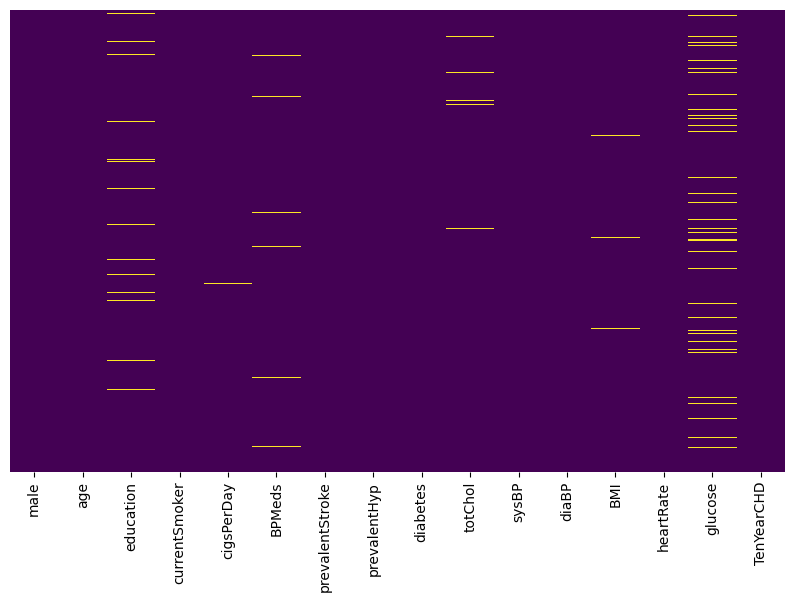

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

### Import IterativeImputer

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

### Create IterativeImputer object with max_iterations and random_state=0

In [7]:
imputer = IterativeImputer(max_iter=10, random_state=0)

### Optional - converting df into numpy array

In [8]:
data = df.values

In [9]:
X = data[:, :-1]
y = data[:, -1]

### Fit the imputer model on dataset to perform iterative multivariate imputation

In [10]:
imputer.fit(X)

,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",None
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False
,"max_iter max_iter: int, default=10Maximum number of imputation rounds to perform before returning theimputations computed during the final round. A round is a singleimputation of each feature with missing values. The stopping criterionis met once `max(abs(X_t - X_{t-1}))/max(abs(X[known_vals])) < tol`,where `X_t` is `X` at iteration `t`. Note that early stopping is onlyapplied if `sample_posterior=False`.",10
,"tol tol: float, default=1e-3Tolerance of the stopping condition.",0.001
,"n_nearest_features n_nearest_features: int, default=NoneNumber of other features to use to estimate the missing values ofeach feature column. Nearness between features is measured usingthe absolute correlation coefficient between each feature pair (afterinitial imputation). To ensure coverage of features throughout theimputation process, the neighbor features are not necessarily nearest,but are drawn with probability proportional to correlation for eachimputed target feature. Can provide significant speed-up when thenumber of features is huge. If `None`, all features will be used.",None
,"initial_strategy initial_strategy: {'mean', 'median', 'most_frequent', 'constant'}, default='mean'Which strategy to use to initialize the missing values. Same as the`strategy` parameter in :class:`~sklearn.impute.SimpleImputer`.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen `strategy=""constant""`, `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types... versionadded:: 1.3",None
,"imputation_order imputation_order: {'ascending', 'descending', 'roman', 'arabic', 'random'}, default='ascending'The order in which the features will be imputed. Possible values:- `'ascending'`: From features with fewest missing values to most.- `'descending'`: From features with most missing values to fewest.- `'roman'`: Left to right.- `'arabic'`: Right to left.- `'random'`: A random order for each round.",'ascending'
,"skip_complete skip_complete: bool, default=FalseIf `True` then features with missing values during :meth:`transform`which did not have any missing values during :meth:`fit` will beimputed with the initial imputation method only. Set to `True` if youhave many features with no missing values at both :meth:`fit` and:meth:`transform` time to save compute.",False
,"min_value min_value: float or array-like of shape (n_features,), default=-np.infMinimum possible imputed value. Broadcast to shape `(n_features,)` ifscalar. If array-like, expects shape `(n_features,)`, one min value foreach feature. The default is `-np.inf`... versionchanged:: 0.23 Added support for array-like.",-inf


### Trained imputer model is applied to dataset to create a copy of dataset with all filled missing values using transform( ) 

In [11]:
X_transform = imputer.transform(X)

### Sanity Check: Whether missing values are filled or not

In [12]:
print(f"Missing cells: {sum(np.isnan(X).flatten())}")

Missing cells: 645


In [13]:
print(f"Missing cells: {sum(np.isnan(X_transform).flatten())}")

Missing cells: 0


### Let's try to visualize the missing values.

<Axes: >

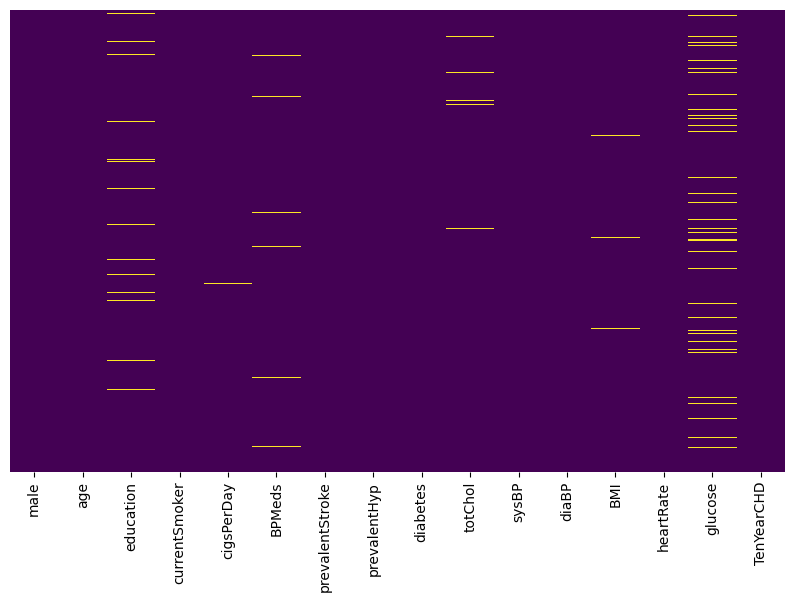

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

In [15]:
#plt.figure(figsize=(10,6))
#sns.heatmap(X_transform.isna(), cbar=False, cmap='viridis', yticklabels=False)

### What's the issue here?
#### Hint: Heatmap needs a DataFrame and not a Numpy Array

In [16]:
df_transform = pd.DataFrame(data=X_transform)
df_transform

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.0,39.0,4.0,0.0,0.0,0.00000,0.0,0.0,0.0,195.0,106.0,70.0,26.97,80.0,77.00000
1,0.0,46.0,2.0,0.0,0.0,0.00000,0.0,0.0,0.0,250.0,121.0,81.0,28.73,95.0,76.00000
2,1.0,48.0,1.0,1.0,20.0,0.00000,0.0,0.0,0.0,245.0,127.5,80.0,25.34,75.0,70.00000
3,0.0,61.0,3.0,1.0,30.0,0.00000,0.0,1.0,0.0,225.0,150.0,95.0,28.58,65.0,103.00000
4,0.0,46.0,3.0,1.0,23.0,0.00000,0.0,0.0,0.0,285.0,130.0,84.0,23.10,85.0,85.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1.0,50.0,1.0,1.0,1.0,0.00000,0.0,1.0,0.0,313.0,179.0,92.0,25.97,66.0,86.00000
4234,1.0,51.0,3.0,1.0,43.0,0.00000,0.0,0.0,0.0,207.0,126.5,80.0,19.71,65.0,68.00000
4235,0.0,48.0,2.0,1.0,20.0,0.01547,0.0,0.0,0.0,248.0,131.0,72.0,22.00,84.0,86.00000
4236,0.0,44.0,1.0,1.0,15.0,0.00000,0.0,0.0,0.0,210.0,126.5,87.0,19.16,86.0,77.74894


<Axes: >

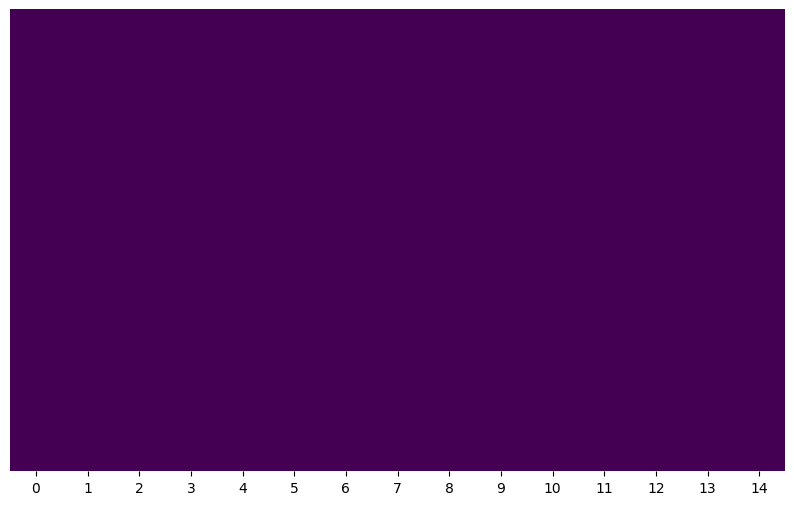

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df_transform.isna(), cbar=False, cmap='viridis', yticklabels=False)

# Check if these datasets contain missing data
### Load the datasets

In [18]:
X_train = pd.read_csv("X_train.csv")
Y_train = pd.read_csv("Y_train.csv")
Y_test = pd.read_csv("Y_test.csv")
X_test = pd.read_csv("X_test.csv")

In [19]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((384, 12), (384, 1), (96, 12), (96, 1))

<Axes: >

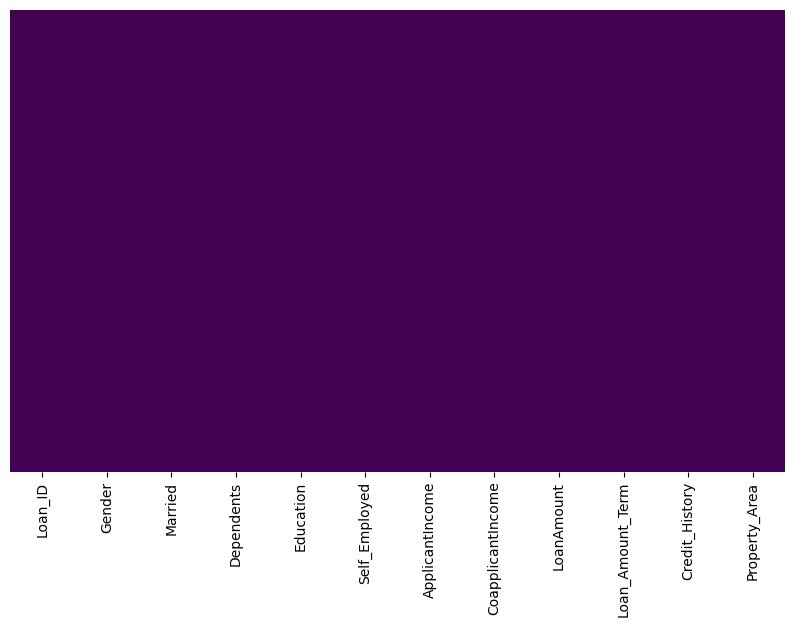

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(X_train.isna(), cbar=False, cmap='viridis', yticklabels=False)

### Is there missing data in this dataset???

According to the heatmap, there's no missing data

# Build a Logistic Regression model Without imputation

In [21]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
X = df[df.columns[:-1]]
y = df[df.columns[-1]]

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [23]:
model = LogisticRegression()

In [24]:
#model.fit(X,y)

# Drop all rows with missing entries - Build a Logistic Regression model and benchmark the accuracy

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [26]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [27]:
df.shape

(4238, 16)

### Drop rows with missing values

In [28]:
df = df.dropna()
df.shape

(3656, 16)

### Split dataset into X and y

In [29]:
X = df[df.columns[:-1]]
X.shape

(3656, 15)

In [30]:
y = df[df.columns[-1]]
y.shape

(3656,)

### Create a pipeline with model parameter

In [31]:
pipeline = Pipeline([('model', model)])

### Create a RepeatedStratifiedKFold with 10 splits and 3 repeats and random_state=1

In [32]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

### Call cross_val_score with pipeline, X, y, accuracy metric and cv

In [33]:
scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

In [34]:
scores

array([0.85245902, 0.85519126, 0.85245902, 0.8442623 , 0.84699454,
       0.84153005, 0.84657534, 0.85753425, 0.84109589, 0.84109589,
       0.85245902, 0.84972678, 0.85519126, 0.8442623 , 0.85519126,
       0.84153005, 0.84109589, 0.84383562, 0.84931507, 0.84657534,
       0.8579235 , 0.84972678, 0.85245902, 0.8442623 , 0.84972678,
       0.84699454, 0.84931507, 0.85205479, 0.84109589, 0.83561644])

### Print the Mean Accuracy and Standard Deviation from scores

In [35]:
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")

Mean Accuracy: 0.848  | Std: 0.006


# Build a Logistic Regression model with IterativeImputer

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [37]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


### Split dataset into X and y

In [38]:
df.shape

(4238, 16)

In [39]:
X = df[df.columns[:-1]]
X.shape

(4238, 15)

In [40]:
y = df[df.columns[-1]]
y

0       0
1       0
2       0
3       1
4       0
       ..
4233    1
4234    0
4235    0
4236    0
4237    0
Name: TenYearCHD, Length: 4238, dtype: int64

### Create a SimpleImputer with mean strategy

In [41]:
imputer = IterativeImputer(max_iter=10, random_state=0)

### Create a Logistic Regression model

In [42]:
model = LogisticRegression()

### Create a pipeline with impute and model parameters

In [43]:
pipeline = Pipeline([('impute', imputer), ('model', model)])

### Create a RepeatedStratifiedKFold with 10 splits and 3 repeats and random_state=1

In [44]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

### Call cross_val_score with pipeline, X, y, accuracy metric and cv

In [45]:
scores2 = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

In [46]:
scores2

array([0.84433962, 0.85377358, 0.84433962, 0.8490566 , 0.84669811,
       0.84669811, 0.8490566 , 0.84669811, 0.84869976, 0.85106383,
       0.8490566 , 0.85377358, 0.8490566 , 0.85377358, 0.84433962,
       0.84669811, 0.84433962, 0.8490566 , 0.8463357 , 0.85106383,
       0.85141509, 0.85141509, 0.84669811, 0.84669811, 0.85377358,
       0.85141509, 0.8490566 , 0.85613208, 0.86052009, 0.84397163])

### Print the Mean Accuracy and Standard Deviation

In [47]:
print(f"Mean Accuracy: {round(np.mean(scores2), 3)}  | Std: {round(np.std(scores2), 3)}")

Mean Accuracy: 0.849  | Std: 0.004


### Which accuracy is better? 
- Dropping missing values
- SimpleImputer with Mean Strategy

In [48]:
print(f"Dropping missing values")
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")
print(f"SimpleImputer with Mean Strategy")
print(f"Mean Accuracy: {round(np.mean(scores2), 3)}  | Std: {round(np.std(scores2), 3)}")

Dropping missing values
Mean Accuracy: 0.848  | Std: 0.006
SimpleImputer with Mean Strategy
Mean Accuracy: 0.849  | Std: 0.004


!!!Using SimpleImputer with Mean Strategy has slightly increased the mean Accuracy!!!

# IterativeImputer with RandomForest

### Import libraries

In [49]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

### Create IterativeImputer

In [50]:
imp_II = IterativeImputer(estimator=LinearRegression(), random_state=1)

### Create RandomForest model

In [51]:
model_RF =  RandomForestClassifier(random_state=1)

### Create Pipeline with Imputer and Model

In [52]:
pipeline_RF = Pipeline(steps=[
    ('imputer', imp_II),
    ('model',   model_RF)
])

### Do CV

In [53]:
cv_RF = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

### Compute Cross_val_score

In [54]:
scores_RF = cross_val_score(pipeline_RF, X, y, scoring='accuracy', cv=cv_RF)

### Print Accuracy

In [55]:
print(f"Mean Accuracy: {round(np.mean(scores_RF), 3)}  | Std: {round(np.std(scores_RF), 3)}")

Mean Accuracy: 0.849  | Std: 0.008


# Run experiments with different Imputation methods and different algorithms

## Imputation Methods
- Mean
- Median
- Most_frequent
- Constant
- IterativeImputer

## ALGORITHMS
- Logistic Regression
- KNN
- Random Forest
- SVM
- Any other algorithm of your choice

In [56]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier

imputers = {
    'mean':             SimpleImputer(strategy='mean'),
    'median':           SimpleImputer(strategy='median'),
    'most_frequent':    SimpleImputer(strategy='most_frequent'),
    'constant':         SimpleImputer(strategy='constant'),
    'IterativeImputer': IterativeImputer(estimator=LinearRegression(), random_state=1)}

models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, solver='saga'),
    'KNN':                  KNeighborsClassifier(),
    'Random Forest':        RandomForestClassifier(random_state=1),
    'SVM':                  SVC(),
    'Decision Tree':        DecisionTreeClassifier(random_state=1),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=1),
    'CatBoost':             CatBoostClassifier(random_state=1, verbose=0)
}

results = []

for imputer_name, imputer in imputers.items():
    for model_name, model in models.items():
        pipeline = Pipeline(steps=[
            ('imputer', imputer),
            ('scaler',  StandardScaler()),
            ('model',   model)
        ])
        cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
        scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv)
        print(f'Imputer: {imputer_name} | Model: {model_name} | Accuracy: {round(scores.mean(), 3)} ± {round(scores.std(), 3)}')
        results.append({
            'Imputer':  imputer_name,
            'Model':    model_name,
            'Accuracy': scores.mean(),
            'Std':      scores.std()
        })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df

Imputer: mean | Model: Logistic Regression | Accuracy: 0.855 ± 0.006
Imputer: mean | Model: KNN | Accuracy: 0.834 ± 0.009
Imputer: mean | Model: Random Forest | Accuracy: 0.849 ± 0.006
Imputer: mean | Model: SVM | Accuracy: 0.848 ± 0.004
Imputer: mean | Model: Decision Tree | Accuracy: 0.754 ± 0.02
Imputer: mean | Model: Gradient Boosting | Accuracy: 0.846 ± 0.008
Imputer: mean | Model: CatBoost | Accuracy: 0.846 ± 0.006
Imputer: median | Model: Logistic Regression | Accuracy: 0.855 ± 0.006
Imputer: median | Model: KNN | Accuracy: 0.835 ± 0.009
Imputer: median | Model: Random Forest | Accuracy: 0.849 ± 0.006
Imputer: median | Model: SVM | Accuracy: 0.848 ± 0.004
Imputer: median | Model: Decision Tree | Accuracy: 0.754 ± 0.019
Imputer: median | Model: Gradient Boosting | Accuracy: 0.846 ± 0.009
Imputer: median | Model: CatBoost | Accuracy: 0.845 ± 0.006
Imputer: most_frequent | Model: Logistic Regression | Accuracy: 0.855 ± 0.006
Imputer: most_frequent | Model: KNN | Accuracy: 0.835 ± 0

,Imputer,Model,Accuracy,Std
14,most_frequent,Logistic Regression,0.854729,0.005773
28,IterativeImputer,Logistic Regression,0.854729,0.005681
0,mean,Logistic Regression,0.854572,0.005802
7,median,Logistic Regression,0.854572,0.005802
21,constant,Logistic Regression,0.853706,0.005733
9,median,Random Forest,0.849382,0.006042
2,mean,Random Forest,0.849381,0.006028
30,IterativeImputer,Random Forest,0.848912,0.007771
23,constant,Random Forest,0.848831,0.006577
16,most_frequent,Random Forest,0.848752,0.005985


# Q1: Which is the best strategy for this dataset using Random Forest algorithm?
- SimpleImputer(Mean)
- SimpleImputer(Median)
- SimpleImputer(Most_frequent)
- SimpleImputer(Constant)
- IterativeImputer

In [57]:
results_df[results_df['Model'] == 'Random Forest'].head(1)['Imputer']

9    median
Name: Imputer, dtype: str

# Q2:  Which is the best algorithm for this dataset using IterativeImputer?
- Logistic Regression
- Random Forest
- KNN
- any other algorithm of your choice (BONUS)

In [58]:
results_df[results_df['Imputer'] == 'IterativeImputer'].head(1)['Model']

28    Logistic Regression
Name: Model, dtype: str

# Q3: Which is the best combination of algorithm and best Imputation Strategy overall?
- Mean , Median, Most_frequent, Constant, IterativeImputer
- Logistic Regression, Random Forest, KNN

In [59]:
results_df.head(1)[['Imputer',"Model"]]

,Imputer,Model
14,most_frequent,Logistic Regression
